# Resampling zipcodes to town resolutions
----------------------------
**Dr. Dave Wanik - University of Connecticut**

I have shown you how to work with both zipcode and town-level data - but how can you aggregate from zipcodes to towns? Let's explore!

# Import modules

In [1]:
!pip install adjustText

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read some shapefiles

In [3]:
# US Zipcode data
# https://drive.google.com/file/d/1atXDaX0OWFmlLzTnjqB_YtmnLYmobaFq/view?usp=drive_link
!gdown 1atXDaX0OWFmlLzTnjqB_YtmnLYmobaFq

Downloading...
From (original): https://drive.google.com/uc?id=1atXDaX0OWFmlLzTnjqB_YtmnLYmobaFq
From (redirected): https://drive.google.com/uc?id=1atXDaX0OWFmlLzTnjqB_YtmnLYmobaFq&confirm=t&uuid=e5ea60c8-6cba-43ce-8e84-a9e35f09de73
To: /content/tl_2017_us_zcta510.zip
100% 533M/533M [00:04<00:00, 110MB/s] 


In [4]:
# the unzipped file dumps left - look at all of those components!
!unzip /content/tl_2017_us_zcta510.zip

Archive:  /content/tl_2017_us_zcta510.zip
 extracting: tl_2017_us_zcta510.cpg  
  inflating: tl_2017_us_zcta510.dbf  
  inflating: tl_2017_us_zcta510.prj  
  inflating: tl_2017_us_zcta510.shp  
  inflating: tl_2017_us_zcta510.shp.ea.iso.xml  
  inflating: tl_2017_us_zcta510.shp.iso.xml  
  inflating: tl_2017_us_zcta510.shp.xml  
  inflating: tl_2017_us_zcta510.shx  


In [5]:
zips = gpd.read_file('tl_2017_us_zcta510.shp')

In [6]:
print(zips.columns)
print(zips.crs) # make sure you have the same CRS

Index(['ZCTA5CE10', 'GEOID10', 'CLASSFP10', 'MTFCC10', 'FUNCSTAT10', 'ALAND10',
       'AWATER10', 'INTPTLAT10', 'INTPTLON10', 'geometry'],
      dtype='object')
EPSG:4269


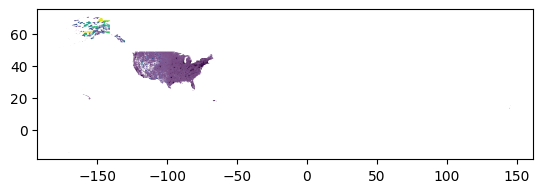

In [7]:
zips.plot(column='ALAND10') # this looks like lat lon
plt.show()

In [11]:
zips.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [8]:
# Northeastern USA Town data (useful for your final project!)
# https://drive.google.com/file/d/1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2/view?usp=sharing
!gdown 1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2

Downloading...
From: https://drive.google.com/uc?id=1cEZBYENFaJ59R1nm0M0E9Q2rqZI6_Yc2
To: /content/Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip
100% 3.30M/3.30M [00:00<00:00, 82.7MB/s]


In [9]:
!unzip Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip

Archive:  Connecticut_and_Vicinity_Town_Boundary_Set_2617795301392764759.zip
  inflating: CT_Vicinity_Town_Polygon.cpg  
  inflating: CT_Vicinity_Town_Polygon.dbf  
  inflating: CT_Vicinity_Town_Polygon.prj  
  inflating: CT_Vicinity_Town_Polygon.shp  
  inflating: CT_Vicinity_Town_Polygon.shx  


Index(['LAND_CLASS', 'CT_LEGEND', 'STATE_COD', 'STATE_NAME', 'CNTY_FIELD',
       'CNTY_COD', 'CNTY_NAME', 'TOWN_FIELD', 'TOWN_NAME', 'LABEL_FLAG',
       'MAP_LABEL', 'CT_LABEL_Y', 'CT_LABEL_N', 'geometry'],
      dtype='object')


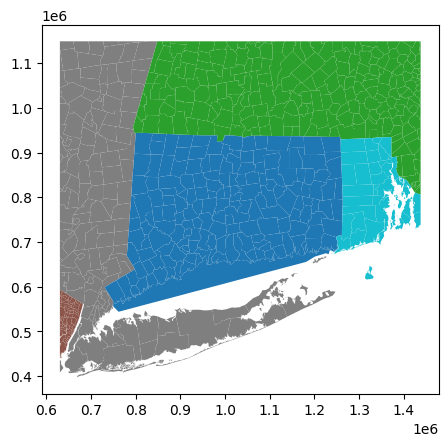

In [10]:
towns = gpd.read_file('CT_Vicinity_Town_Polygon.shp')
print(towns.columns)
towns.plot(column='STATE_COD')
plt.show()

In [ ]:
towns.crs # 2234 means we are in FEET!
# need to convert if we are going to resample these things

<Projected CRS: EPSG:2234>
Name: NAD83 / Connecticut (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - Connecticut - counties of Fairfield; Hartford; Litchfield; Middlesex; New Haven; New London; Tolland; Windham.
- bounds: (-73.73, 40.98, -71.78, 42.05)
Coordinate Operation:
- name: SPCS83 Connecticut zone (US Survey feet)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [12]:
# prompt: change crs of towns from 2234 to crs of zips

towns.to_crs(zips.crs, inplace=True)
towns.crs


<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

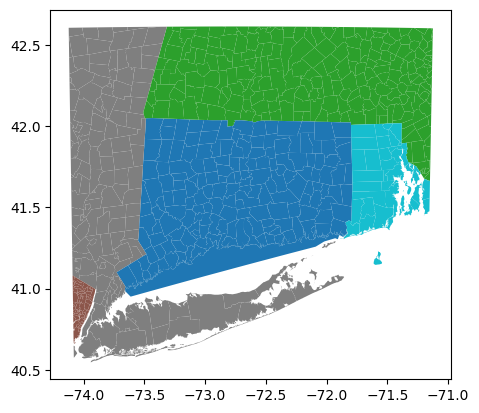

In [13]:
towns.plot(column='STATE_COD') # now it's lat/lon!
plt.show()

In [14]:
towns.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry
0,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Uxbridge,True,Uxbridge,None,Uxbridge,"POLYGON ((-71.59192 42.06371, -71.59273 42.114..."
1,Land,Other States,MA,Massachusetts,FIPS-COUNTY,21.0,Norfolk,TOWN-ID,Foxborough,True,Foxborough,None,Foxborough,"POLYGON ((-71.17836 42.05746, -71.19620 42.082..."
2,Land,Other States,MA,Massachusetts,FIPS-COUNTY,27.0,Worcester,TOWN-ID,Southbridge,True,Southbridge,None,Southbridge,"POLYGON ((-71.99294 42.07255, -71.99257 42.078..."
3,Land,Other States,MA,Massachusetts,FIPS-COUNTY,5.0,Bristol,TOWN-ID,Easton,True,Easton,None,Easton,"POLYGON ((-71.14082 41.99879, -71.13898 42.072..."
4,Land,Other States,MA,Massachusetts,FIPS-COUNTY,13.0,Hamden,TOWN-ID,Agawam,True,Agawam,None,Agawam,"POLYGON ((-72.58852 42.09324, -72.58877 42.093..."


# Read a census data file
This is one of my favorite sources for zipcode-level Census data:
* https://github.com/Ro-Data/Ro-Census-Summaries-By-Zipcode

In [15]:
# https://drive.google.com/file/d/1qms7rRvl_1Q5afDpC5AWpVrNnZP9KtrL/view?usp=sharing
!gdown 1qms7rRvl_1Q5afDpC5AWpVrNnZP9KtrL

Downloading...
From: https://drive.google.com/uc?id=1qms7rRvl_1Q5afDpC5AWpVrNnZP9KtrL
To: /content/econ.txt
100% 49.7M/49.7M [00:00<00:00, 163MB/s]


In [16]:
econ = pd.read_csv('/content/econ.txt', sep='\t')
econ.head()

,ZCTA5,employment_status-population-population_16_years_and_over,employment_status-population-in_labor_force_population_16_years_and_over,employment_status-percent-in_labor_force-of-population_16_years_and_over,employment_status-population-in_civilian_labor_force_population_16_years_and_over,employment_status-percent-in_civilian_labor_force-of-population_16_years_and_over,employment_status-population-employed_population_16_years_and_over,employment_status-percent-employed-of-population_16_years_and_over,employment_status-population-unemployed_population_16_years_and_over,employment_status-percent-unemployed-of-population_16_years_and_over,...,people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_5_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_5_to_17_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_to_64_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-65_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-people_in_families-of-all_families,people_whose_income_in_past_12m_is_below_poverty_level-percent-unrelated_individuals_15_years_and_over-of-all_families
0,601,14169,6056,0.427,6056,0.427,3904,0.276,2152,0.152,...,0.624,0.758,0.758,0.876,0.724,0.583,0.587,0.569,0.613,0.702
1,602,32545,14707,0.452,14676,0.451,11560,0.355,3116,0.096,...,0.545,0.651,0.651,0.794,0.608,0.517,0.535,0.442,0.529,0.664
2,603,41976,16565,0.395,16490,0.393,12722,0.303,3768,0.090,...,0.507,0.645,0.640,0.723,0.614,0.468,0.483,0.421,0.482,0.639
3,606,5160,1672,0.324,1672,0.324,1467,0.284,205,0.040,...,0.640,0.789,0.789,0.918,0.744,0.603,0.657,0.402,0.624,0.738
4,610,22916,9914,0.433,9914,0.433,8327,0.363,1587,0.069,...,0.493,0.621,0.621,0.612,0.623,0.458,0.480,0.384,0.477,0.603


In [17]:
# prompt: add leading 0s to ZCTA5 so each is 5 long

econ['ZCTA5'] = econ['ZCTA5'].astype(str)
econ['ZCTA5'] = econ['ZCTA5'].apply(lambda x: x.zfill(5))


In [18]:
# check your work
econ.head()

,ZCTA5,employment_status-population-population_16_years_and_over,employment_status-population-in_labor_force_population_16_years_and_over,employment_status-percent-in_labor_force-of-population_16_years_and_over,employment_status-population-in_civilian_labor_force_population_16_years_and_over,employment_status-percent-in_civilian_labor_force-of-population_16_years_and_over,employment_status-population-employed_population_16_years_and_over,employment_status-percent-employed-of-population_16_years_and_over,employment_status-population-unemployed_population_16_years_and_over,employment_status-percent-unemployed-of-population_16_years_and_over,...,people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_5_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_5_to_17_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_to_64_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-65_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-people_in_families-of-all_families,people_whose_income_in_past_12m_is_below_poverty_level-percent-unrelated_individuals_15_years_and_over-of-all_families
0,00601,14169,6056,0.427,6056,0.427,3904,0.276,2152,0.152,...,0.624,0.758,0.758,0.876,0.724,0.583,0.587,0.569,0.613,0.702
1,00602,32545,14707,0.452,14676,0.451,11560,0.355,3116,0.096,...,0.545,0.651,0.651,0.794,0.608,0.517,0.535,0.442,0.529,0.664
2,00603,41976,16565,0.395,16490,0.393,12722,0.303,3768,0.090,...,0.507,0.645,0.640,0.723,0.614,0.468,0.483,0.421,0.482,0.639
3,00606,5160,1672,0.324,1672,0.324,1467,0.284,205,0.040,...,0.640,0.789,0.789,0.918,0.744,0.603,0.657,0.402,0.624,0.738
4,00610,22916,9914,0.433,9914,0.433,8327,0.363,1587,0.069,...,0.493,0.621,0.621,0.612,0.623,0.458,0.480,0.384,0.477,0.603


# Join `econ` to the zipcode map

In [19]:
econ.columns

Index(['ZCTA5', 'employment_status-population-population_16_years_and_over',
       'employment_status-population-in_labor_force_population_16_years_and_over',
       'employment_status-percent-in_labor_force-of-population_16_years_and_over',
       'employment_status-population-in_civilian_labor_force_population_16_years_and_over',
       'employment_status-percent-in_civilian_labor_force-of-population_16_years_and_over',
       'employment_status-population-employed_population_16_years_and_over',
       'employment_status-percent-employed-of-population_16_years_and_over',
       'employment_status-population-unemployed_population_16_years_and_over',
       'employment_status-percent-unemployed-of-population_16_years_and_over',
       ...
       'people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people',
       'people_whose_income_in_past_12m_is_below_poverty_level-percent-under_18_years-of-all_people',
       'people_whose_income_in_past_12m_is_below_pover

In [23]:
econ.shape

(33120, 225)

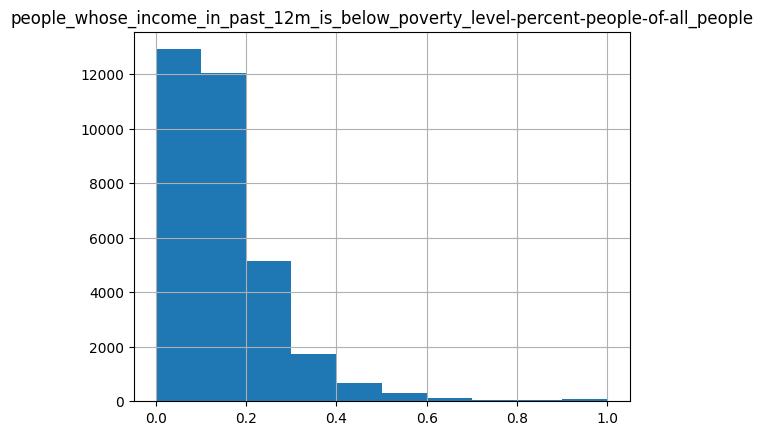

In [20]:
# it looks like this is a percentage between 0 and 1 (100)
econ['people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people'].hist()
plt.title('people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people')
plt.show()

In [21]:
# prompt: Join econ to the zipcode map and keep as geodataframe

# Join econ to the zipcode map
econ_zips = zips.merge(econ, left_on='ZCTA5CE10', right_on='ZCTA5', how='left')
econ_zips.head()
print(econ_zips.shape)

(33144, 235)


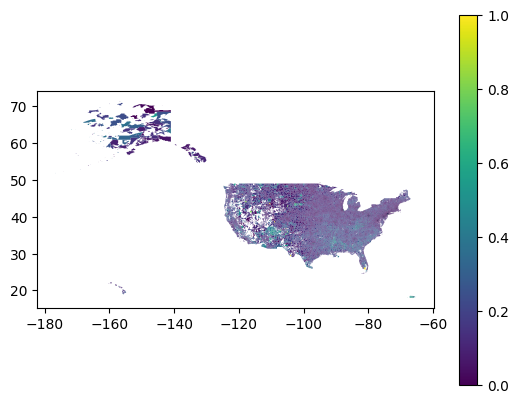

In [22]:
econ_zips.plot(column='people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people',
               legend=True)
plt.show()

The zipcode data is AMAZING!!! But what if you wanted to report some of this information out by town in New England?

# Spatial intersection/resampling
Why don't we take a weighted average? And for simplicity, let's focus just on CT so we can see what's going on.

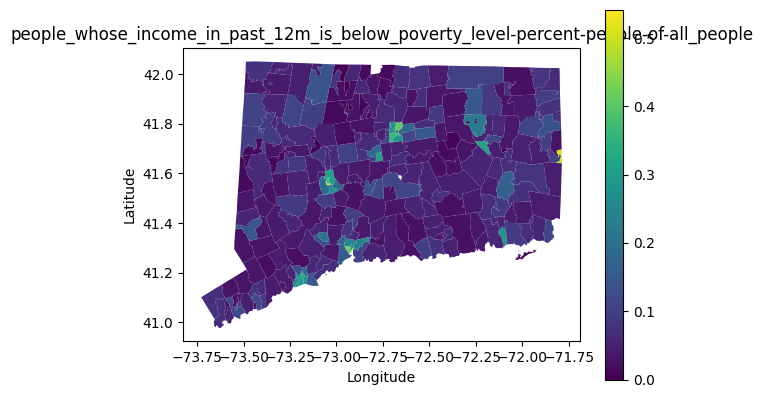

In [30]:
# prompt: select rows where ZCTA5CE10 begins with 06

econ_zips_ct = econ_zips[econ_zips['ZCTA5CE10'].str.startswith('06')]
econ_zips_ct.plot(column='people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people',
                  legend=True)
plt.title('people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people')
plt.ylabel('Latitude')
plt.xlabel('Longitude')
plt.show()

In [31]:
econ_zips_ct.shape

(283, 235)

Obviously, this has a different shape than the CT town data. Zipcodes are usually higher-resolution that town data! This means there are more zipcodes than towns.

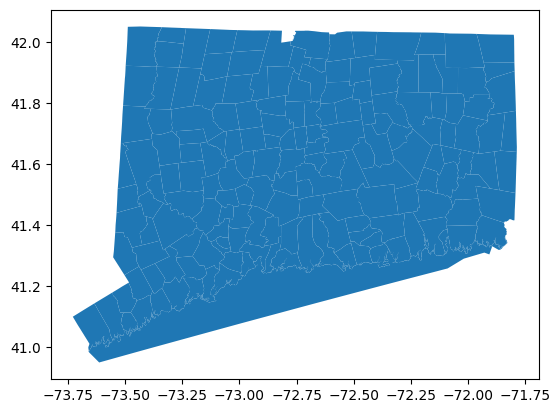

In [32]:
towns = towns[towns['STATE_COD']=='CT']
towns.plot()
plt.show()

In [33]:
towns.shape

(784, 14)

In [ ]:
towns.head()

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,Salisbury,Salisbury,None,"POLYGON ((-73.34064 42.04836, -73.34434 42.048..."
25,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,North Canaan,True,North Canaan,North Canaan,None,"POLYGON ((-73.29629 42.04699, -73.30315 42.047..."
26,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Norfolk,True,Norfolk,Norfolk,None,"POLYGON ((-73.17214 42.04339, -73.18613 42.043..."
27,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Colebrook,True,Colebrook,Colebrook,None,"POLYGON ((-73.05308 42.03978, -73.05856 42.039..."
28,Land,Connecticut,CT,Connecticut,CNTY_COD,2.0,Hartford,TOWN_NO,Hartland,True,Hartland,Hartland,None,"POLYGON ((-72.97902 42.03825, -72.97983 42.038..."


# Intersection

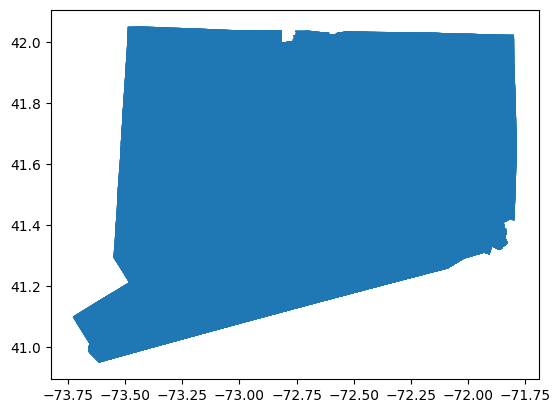

,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,...,people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_5_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_5_to_17_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_to_64_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-65_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-people_in_families-of-all_families,people_whose_income_in_past_12m_is_below_poverty_level-percent-unrelated_individuals_15_years_and_over-of-all_families
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.104,0.181,0.181,0.200,0.177,0.096,0.087,0.115,0.061,0.245
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.053,0.020,0.020,0.333,0.000,0.058,0.078,0.035,0.015,0.227
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.038,0.013,0.000,0.000,0.000,0.042,0.059,0.000,0.014,0.121
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.037,0.000,0.000,0.000,0.000,0.045,0.046,0.044,0.011,0.133
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.049,0.099,0.099,0.091,0.101,0.036,0.035,0.043,0.035,0.089


In [35]:
# prompt: calculate the weighted average of column='people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people' from econ_zips_ct to town resolution

# Let's use the `sjoin` function to intersect the zipcode layer to the town layer.
# We will use the `how='left'` argument to ensure that all towns are included in the output, even if they do not intersect with any zipcodes.
town_econ = gpd.sjoin(towns, econ_zips_ct, how='left', predicate='intersects')
town_econ.plot()
plt.show()

town_econ.head()

In [36]:
town_econ.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 1921 entries, 22 to 1779
Columns: 249 entries, LAND_CLASS to people_whose_income_in_past_12m_is_below_poverty_level-percent-unrelated_individuals_15_years_and_over-of-all_families
dtypes: float64(228), geometry(1), object(20)
memory usage: 3.7+ MB


In [37]:
# Now we need to calculate the weighted average of the poverty rate for each town.
# The weights will be the proportion of the town's area that is covered by each zipcode.
# We can use the `area` column from the zipcode layer for this.
town_econ['ALAND10'] = town_econ['ALAND10'] / 1e6  # convert to square kilometers
town_econ['area_weight'] = town_econ['ALAND10'] / town_econ.groupby('TOWN_NAME')['ALAND10'].transform('sum')
town_econ.head()
town_econ['weighted_poverty_rate'] = town_econ['area_weight'] * town_econ['people_whose_income_in_past_12m_is_below_poverty_level-percent-people-of-all_people']
print(town_econ.shape)
town_econ.head()


(1921, 251)


,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,...,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_18_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_under_5_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-related_children_5_to_17_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-18_to_64_years-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-65_years_and_over-of-all_people,people_whose_income_in_past_12m_is_below_poverty_level-percent-people_in_families-of-all_families,people_whose_income_in_past_12m_is_below_poverty_level-percent-unrelated_individuals_15_years_and_over-of-all_families,area_weight,weighted_poverty_rate
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.181,0.200,0.177,0.096,0.087,0.115,0.061,0.245,0.264103,0.027467
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.020,0.333,0.000,0.058,0.078,0.035,0.015,0.227,0.195909,0.010383
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.000,0.000,0.000,0.042,0.059,0.000,0.014,0.121,0.202698,0.007703
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.000,0.000,0.000,0.045,0.046,0.044,0.011,0.133,0.110632,0.004093
22,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,...,0.099,0.091,0.101,0.036,0.035,0.043,0.035,0.089,0.062709,0.003073


In [38]:
# Finally, we can group the data by town and calculate the weighted average of the poverty rate for each town.
town_poverty = town_econ.groupby('TOWN_NAME')['weighted_poverty_rate'].mean()
print(town_poverty.shape) # 169 towns!
town_poverty.head()

(169,)


TOWN_NAME
Andover        0.004910
Ansonia        0.019519
Ashford        0.015409
Avon           0.003990
Barkhamsted    0.010949
Name: weighted_poverty_rate, dtype: float64

# Now join it back and make a map!

In [39]:
# Join econ to the zipcode map
tmp = towns.merge(town_poverty, left_on='TOWN_NAME', right_on='TOWN_NAME', how='left')
print(tmp.shape)
tmp.head()


(784, 15)


,LAND_CLASS,CT_LEGEND,STATE_COD,STATE_NAME,CNTY_FIELD,CNTY_COD,CNTY_NAME,TOWN_FIELD,TOWN_NAME,LABEL_FLAG,MAP_LABEL,CT_LABEL_Y,CT_LABEL_N,geometry,weighted_poverty_rate
0,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Salisbury,True,Salisbury,Salisbury,None,"POLYGON ((-73.34064 42.04836, -73.34434 42.048...",0.010972
1,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,North Canaan,True,North Canaan,North Canaan,None,"POLYGON ((-73.29629 42.04699, -73.30315 42.047...",0.010579
2,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Norfolk,True,Norfolk,Norfolk,None,"POLYGON ((-73.17214 42.04339, -73.18613 42.043...",0.011657
3,Land,Connecticut,CT,Connecticut,CNTY_COD,3.0,Litchfield,TOWN_NO,Colebrook,True,Colebrook,Colebrook,None,"POLYGON ((-73.05308 42.03978, -73.05856 42.039...",0.016865
4,Land,Connecticut,CT,Connecticut,CNTY_COD,2.0,Hartford,TOWN_NO,Hartland,True,Hartland,Hartland,None,"POLYGON ((-72.97902 42.03825, -72.97983 42.038...",0.010674


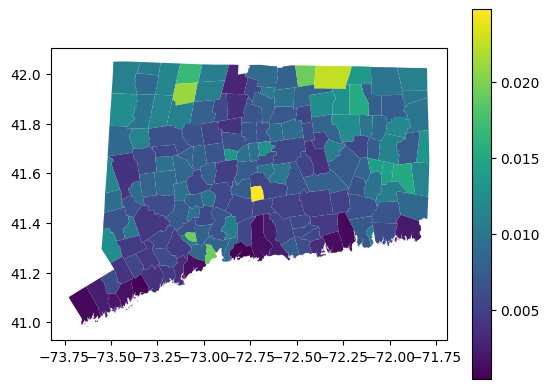

In [40]:
tmp.plot(column='weighted_poverty_rate', legend=True)
plt.show()

This geodataframe has incredible information! If you run the resampling code for different variables, you can take this zipcode-level data and present it as town data - even though you don't have a primary key. The geometry (location) is the primary key!!! How awesome is that?!